In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp

def retrato(A, ax, lim=3, titulo=None, autovetores=True):
    # Desenha o retrato de fase de x' = A x no quadrado [-lim, lim]^2
    A = np.array(A, dtype=float)
    s = np.linspace(-lim, lim, 40)
    X, Y = np.meshgrid(s, s)
    U = A[0, 0]*X + A[0, 1]*Y
    V = A[1, 0]*X + A[1, 1]*Y
    ax.streamplot(X, Y, U, V, color='0.55', density=1.1, linewidth=0.8, arrowsize=1)
    if autovetores:
        lam, vec = np.linalg.eig(A)
        if np.all(np.abs(lam.imag) < 1e-12):
            pares = list(zip(lam.real, vec.T.real))
            if abs(lam[0] - lam[1]) < 1e-6:
                pares = pares[:1]
            for l, v in pares:
                ax.plot([-3*lim*v[0], 3*lim*v[0]], [-3*lim*v[1], 3*lim*v[1]],
                        '--', linewidth=2, label=fr'$\lambda={l:.3g}$')
            ax.legend(loc='lower right', fontsize=8)
    ax.plot(0, 0, 'ko', markersize=5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    if titulo:
        ax.set_title(titulo)

def trajetoria(A, x0, T, ax, cor='b'):
    # Integra x' = A x a partir de x0 e desenha a trajetória
    A = np.array(A, dtype=float)
    sol = solve_ivp(lambda t, x: A @ x, (0, T), x0, max_step=T/500)
    ax.plot(sol.y[0], sol.y[1], color=cor, linewidth=2.5)
    ax.plot(x0[0], x0[1], 'o', color=cor, markersize=7)
    return sol

u é solução? Matrix([[0, 0]])    w é solução? Matrix([[0, 0]])


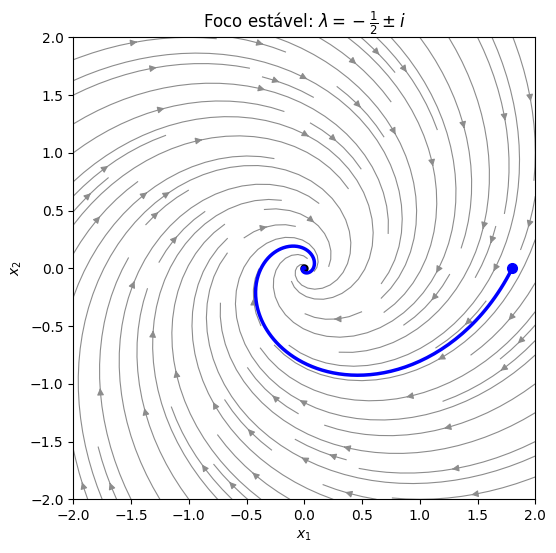

In [2]:
t = sp.symbols('t', real=True)
A = sp.Matrix([[-sp.Rational(1, 2), 1], [-1, -sp.Rational(1, 2)]])
u = sp.exp(-t/2)*sp.Matrix([sp.cos(t), -sp.sin(t)])
w = sp.exp(-t/2)*sp.Matrix([sp.sin(t), sp.cos(t)])
print("u é solução?", sp.simplify(u.diff(t) - A*u).T, "   w é solução?", sp.simplify(w.diff(t) - A*w).T)

fig, ax = plt.subplots(figsize=(6, 6))
retrato(np.array(A, dtype=float), ax, lim=2, titulo=r"Foco estável: $\lambda=-\frac{1}{2}\pm i$")
trajetoria(np.array(A, dtype=float), [1.8, 0], 12, ax, cor='b')
plt.show()

Foco estável ($\gamma=0{,}8$) -> autovalores: [-0.4+1.96j -0.4-1.96j]
Centro ($\gamma=0$) -> autovalores: [ 0.+2.j -0.-2.j]


Foco instável ($\gamma=-0{,}4$) -> autovalores: [0.2+1.99j 0.2-1.99j]


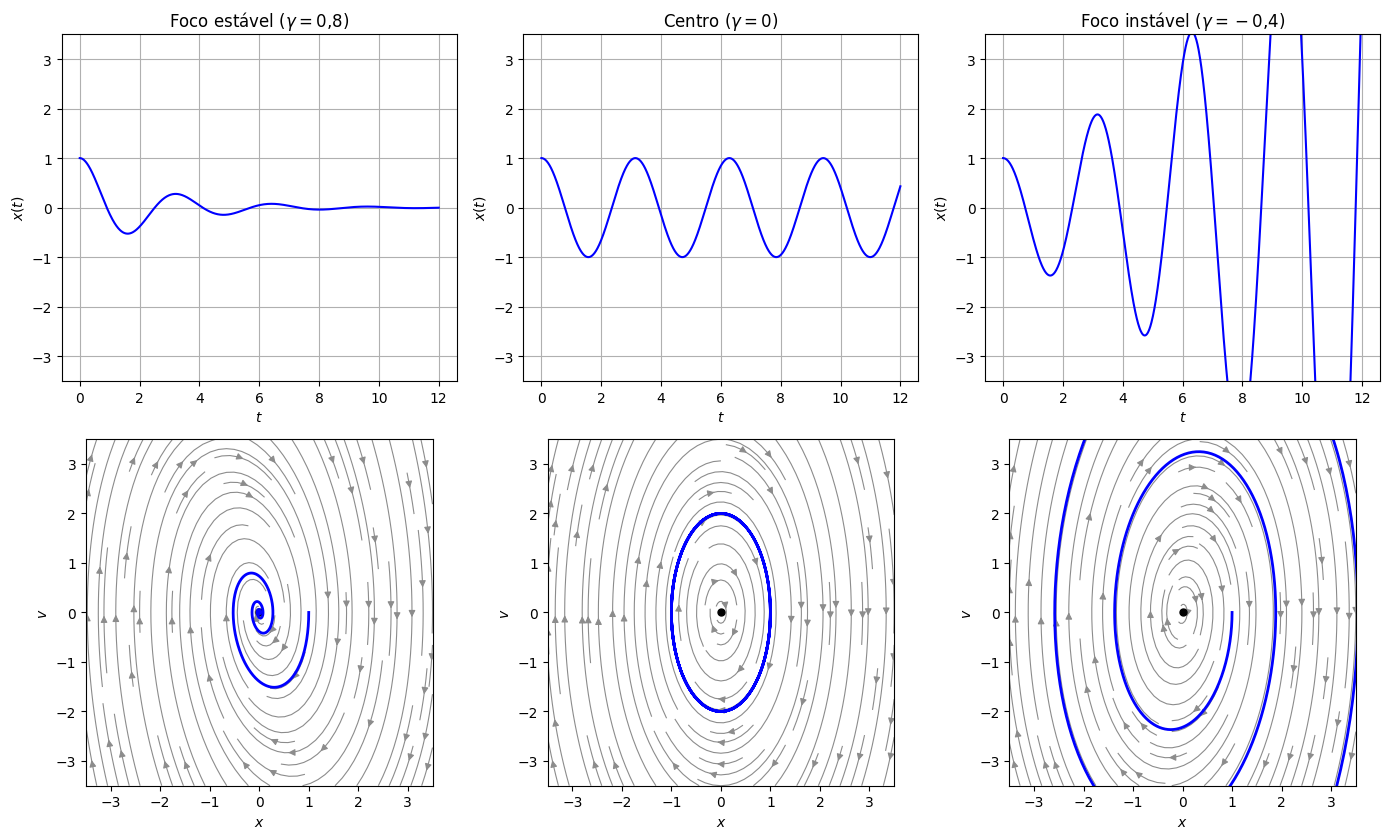

In [3]:
k = 4
casos = [(0.8, "Foco estável ($\\gamma=0{,}8$)"),
         (0.0, "Centro ($\\gamma=0$)"),
         (-0.4, "Foco instável ($\\gamma=-0{,}4$)")]

fig, axs = plt.subplots(2, 3, figsize=(14, 8.5))
for j, (gamma, titulo) in enumerate(casos):
    A = np.array([[0, 1], [-k, -gamma]])
    print(titulo, "-> autovalores:", np.round(np.linalg.eigvals(A), 3))
    tt = np.linspace(0, 12, 1000)
    sol = solve_ivp(lambda t, x: A @ x, (0, 12), [1, 0], t_eval=tt)
    axs[0, j].plot(tt, sol.y[0], 'b')
    axs[0, j].set_title(titulo); axs[0, j].set_xlabel("$t$"); axs[0, j].set_ylabel("$x(t)$")
    axs[0, j].set_ylim(-3.5, 3.5); axs[0, j].grid(True)
    retrato(A, axs[1, j], lim=3.5)
    axs[1, j].plot(sol.y[0], sol.y[1], 'b', linewidth=2)
    axs[1, j].set_xlabel("$x$"); axs[1, j].set_ylabel("$v$")
plt.tight_layout()
plt.show()